# Importing important libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve, precision_recall_curve
)

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


# Component 1 — Streaming Service Dataset (Supervised + Unsupervised Learning)

This notebook answers the Component 1 questions (a)–(h):

**Regression target:** `Monthly_Spend`  
**Classification target:** `Churned`

The work includes:
- Linear vs Polynomial regression for each numeric predictor
- Multiple Linear Regression
- Random Forest Regression (numeric + categorical)
- ANN Regression (all features)
- Churn classification (Logistic Regression vs Random Forest)
- k-Means clustering + comparison with Hierarchical clustering

All results are supported with tables and plots for inclusion in the report.


In [2]:
df = pd.read_csv("Streaming.csv")
df.head()

,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1
4,CUST000005,60.0,Male,6,East,Credit Card,2,NaN,13.18,65,45.97,0


In [3]:
shape_table = pd.DataFrame({"Rows":[df.shape[0]], "Columns":[df.shape[1]]})
shape_table


,Rows,Columns
0,5000,12


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer_ID             5000 non-null   object 
 1   Age                     4500 non-null   float64
 2   Gender                  5000 non-null   object 
 3   Subscription_Length     5000 non-null   int64  
 4   Region                  5000 non-null   object 
 5   Payment_Method          5000 non-null   object 
 6   Support_Tickets_Raised  5000 non-null   int64  
 7   Satisfaction_Score      4500 non-null   float64
 8   Discount_Offered        5000 non-null   float64
 9   Last_Activity           5000 non-null   int64  
 10  Monthly_Spend           5000 non-null   float64
 11  Churned                 5000 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [5]:
missing_table = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_%": (df.isna().sum() / len(df) * 100).round(2)
}).sort_values("Missing_Count", ascending=False)

missing_table


,Missing_Count,Missing_%
Age,500,10.0
Satisfaction_Score,500,10.0
Customer_ID,0,0.0
Gender,0,0.0
Subscription_Length,0,0.0
Region,0,0.0
Payment_Method,0,0.0
Support_Tickets_Raised,0,0.0
Discount_Offered,0,0.0
Last_Activity,0,0.0


## Data Cleaning and Pre-processing

Cleaning is required to ensure models are trained on valid inputs and results are reliable:

- `Customer_ID` is an identifier (not predictive), so it is removed.
- Missing values in numerical columns (e.g., `Age`, `Satisfaction_Score`) are imputed using the median.
- Numeric and categorical features are separated so that scaling and one-hot encoding can be applied appropriately.


In [6]:
df = df.drop(columns=["Customer_ID"])

# Median imputation (robust to outliers)
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Satisfaction_Score"] = df["Satisfaction_Score"].fillna(df["Satisfaction_Score"].median())

df.isna().sum()


Age                       0
Gender                    0
Subscription_Length       0
Region                    0
Payment_Method            0
Support_Tickets_Raised    0
Satisfaction_Score        0
Discount_Offered          0
Last_Activity             0
Monthly_Spend             0
Churned                   0
dtype: int64

In [7]:
y_spend = df["Monthly_Spend"]
y_churn = df["Churned"].astype(int)

X = df.drop(columns=["Monthly_Spend", "Churned"])

num_cols = [
    "Age",
    "Subscription_Length",
    "Support_Tickets_Raised",
    "Satisfaction_Score",
    "Discount_Offered",
    "Last_Activity"
]

cat_cols = ["Gender", "Region", "Payment_Method"]

num_cols, cat_cols


(['Age',
  'Subscription_Length',
  'Support_Tickets_Raised',
  'Satisfaction_Score',
  'Discount_Offered',
  'Last_Activity'],
 ['Gender', 'Region', 'Payment_Method'])

In [8]:
desc_num = df[num_cols + ["Monthly_Spend"]].describe().T
desc_num


,count,mean,std,min,25%,50%,75%,max
Age,5000.0,43.524000,14.202287,18.00,32.0000,43.000,55.00,69.00
Subscription_Length,5000.0,29.704400,17.050336,1.00,15.0000,29.000,44.00,59.00
Support_Tickets_Raised,5000.0,2.037000,1.422405,0.00,1.0000,2.000,3.00,9.00
Satisfaction_Score,5000.0,5.591400,2.725423,1.00,3.0000,6.000,8.00,10.00
Discount_Offered,5000.0,12.458404,4.325381,5.00,8.7000,12.500,16.19,20.00
Last_Activity,5000.0,181.441400,104.500951,1.00,90.0000,182.000,271.00,364.00
Monthly_Spend,5000.0,46.619784,9.522140,-5.06,39.8975,46.625,53.21,137.31


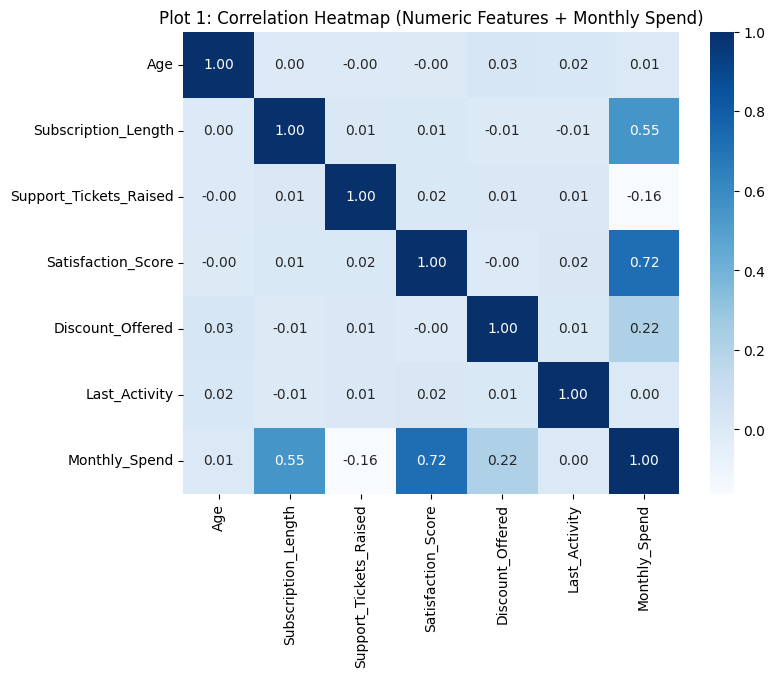

In [9]:
plt.figure(figsize=(8,6))
corr = df[num_cols + ["Monthly_Spend"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Plot 1: Correlation Heatmap (Numeric Features + Monthly Spend)")
plt.show()


## (a) Single-feature regression (Linear vs Polynomial)

For each numerical feature, three models are compared:
- Linear Regression
- Polynomial Regression (degree 2)
- Polynomial Regression (degree 3)

Performance is evaluated using:
- MAE (lower is better)
- RMSE (lower is better)
- R² (higher is better)


In [10]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


In [11]:
X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    df[num_cols], y_spend, test_size=0.2, random_state=42
)


In [12]:
results_a = []

for feature in num_cols:
    Xt_train = X_train_a[[feature]]
    Xt_test = X_test_a[[feature]]

    # Linear
    lin = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
    lin.fit(Xt_train, y_train_a)
    pred_lin = lin.predict(Xt_test)
    mae, rmse, r2 = regression_metrics(y_test_a, pred_lin)
    results_a.append({"Feature": feature, "Model": "Linear", "MAE": mae, "RMSE": rmse, "R2": r2})

    # Polynomial degrees
    for deg in [2, 3]:
        poly = Pipeline([
            ("scaler", StandardScaler()),
            ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
            ("model", LinearRegression())
        ])
        poly.fit(Xt_train, y_train_a)
        pred_poly = poly.predict(Xt_test)
        mae, rmse, r2 = regression_metrics(y_test_a, pred_poly)
        results_a.append({"Feature": feature, "Model": f"Polynomial (deg={deg})", "MAE": mae, "RMSE": rmse, "R2": r2})

results_a_df = pd.DataFrame(results_a).sort_values(["MAE", "RMSE"])
results_a_df


,Feature,Model,MAE,RMSE,R2
9,Satisfaction_Score,Linear,5.160335,6.487249,0.534467
10,Satisfaction_Score,Polynomial (deg=2),5.161274,6.486895,0.534518
11,Satisfaction_Score,Polynomial (deg=3),5.162623,6.488365,0.534307
3,Subscription_Length,Linear,6.642847,8.051573,0.282882
4,Subscription_Length,Polynomial (deg=2),6.645539,8.056445,0.282014
5,Subscription_Length,Polynomial (deg=3),6.649370,8.061746,0.281069
12,Discount_Offered,Linear,7.421164,9.293519,0.044591
13,Discount_Offered,Polynomial (deg=2),7.421171,9.293517,0.044591
14,Discount_Offered,Polynomial (deg=3),7.423299,9.295767,0.044129
6,Support_Tickets_Raised,Linear,7.600181,9.423111,0.017760


/Users/meez/tf_env/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


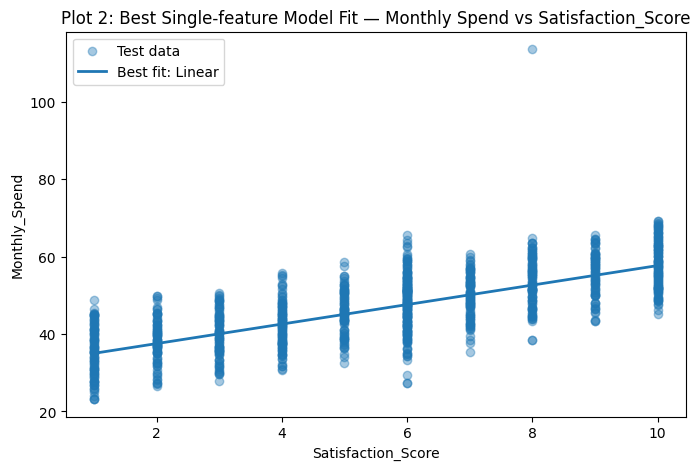

In [13]:
best_a = results_a_df.iloc[0]
best_feature = best_a["Feature"]
best_model = best_a["Model"]

Xt = df[[best_feature]]
yt = y_spend

Xt_train, Xt_test, yt_train, yt_test = train_test_split(Xt, yt, test_size=0.2, random_state=42)

if best_model == "Linear":
    pipe = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
else:
    deg = int(best_model.split("deg=")[1].replace(")", ""))
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=deg, include_bias=False)),
        ("model", LinearRegression())
    ])

pipe.fit(Xt_train, yt_train)

x_line = np.linspace(Xt.min().values[0], Xt.max().values[0], 300).reshape(-1, 1)
y_line = pipe.predict(x_line)

plt.figure(figsize=(8,5))
plt.scatter(Xt_test, yt_test, alpha=0.4, label="Test data")
plt.plot(x_line, y_line, linewidth=2, label=f"Best fit: {best_model}")
plt.xlabel(best_feature)
plt.ylabel("Monthly_Spend")
plt.title(f"Plot 2: Best Single-feature Model Fit — Monthly Spend vs {best_feature}")
plt.legend()
plt.show()


## (b) Multiple Linear Regression (numerical variables)

A Multiple Linear Regression model is trained using **all numerical features**.
Performance is compared to the best single-feature model from (a).


In [14]:
multi_lin = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
multi_lin.fit(X_train_a, y_train_a)
pred_b = multi_lin.predict(X_test_a)

b_mae, b_rmse, b_r2 = regression_metrics(y_test_a, pred_b)

pd.DataFrame([{
    "Model": "Multiple Linear Regression (Numeric only)",
    "MAE": b_mae, "RMSE": b_rmse, "R2": b_r2
}])


,Model,MAE,RMSE,R2
0,Multiple Linear Regression (Numeric only),1.358476,3.208505,0.886123


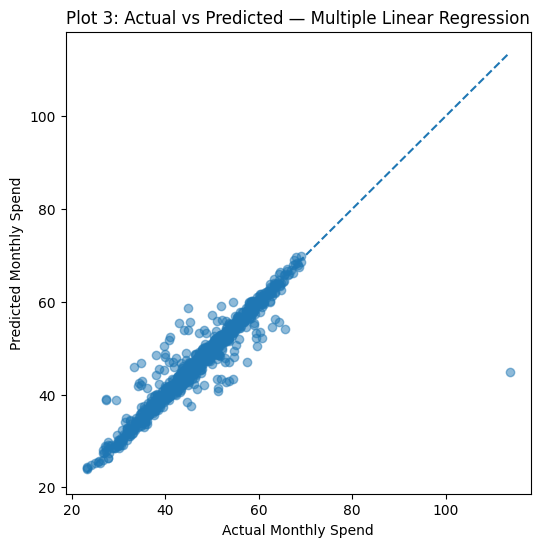

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_a, pred_b, alpha=0.5)
plt.plot([y_test_a.min(), y_test_a.max()], [y_test_a.min(), y_test_a.max()], linestyle="--")
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")
plt.title("Plot 3: Actual vs Predicted — Multiple Linear Regression")
plt.show()


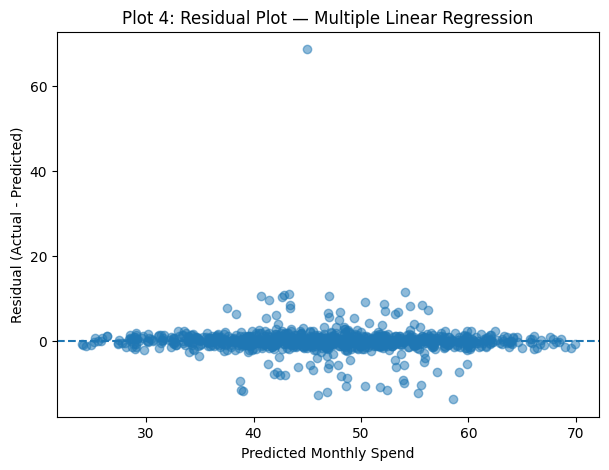

In [16]:
residuals = y_test_a - pred_b

plt.figure(figsize=(7,5))
plt.scatter(pred_b, residuals, alpha=0.5)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Monthly Spend")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Plot 4: Residual Plot — Multiple Linear Regression")
plt.show()


## (c) Random Forest Regression using numerical + categorical variables

To capture non-linear relationships and interactions, a Random Forest Regressor is trained
using all features. Categorical features are one-hot encoded, numerical features are scaled.

The model is evaluated on a held-out test set (80/20 split).


In [17]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)


In [18]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_spend, test_size=0.2, random_state=42
)

rf_reg = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestRegressor(n_estimators=300, random_state=42))
])

rf_reg.fit(X_train_c, y_train_c)
pred_c = rf_reg.predict(X_test_c)

c_mae, c_rmse, c_r2 = regression_metrics(y_test_c, pred_c)

pd.DataFrame([{
    "Model": "Random Forest Regressor (Numeric + Categorical)",
    "MAE": c_mae, "RMSE": c_rmse, "R2": c_r2
}])


,Model,MAE,RMSE,R2
0,Random Forest Regressor (Numeric + Categorical),1.805876,3.460493,0.867534


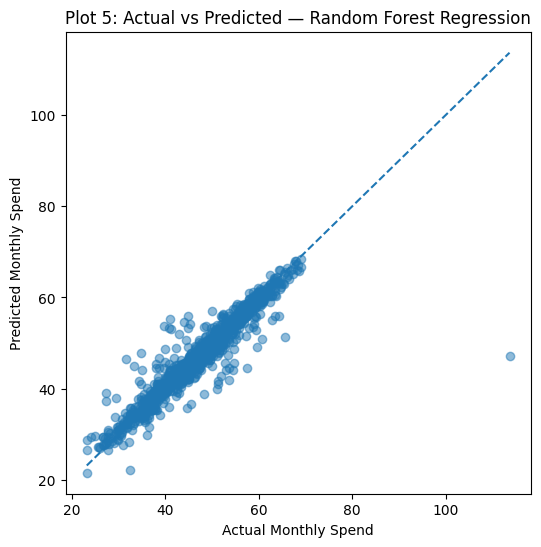

In [19]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_c, pred_c, alpha=0.5)
plt.plot([y_test_c.min(), y_test_c.max()], [y_test_c.min(), y_test_c.max()], linestyle="--")
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")
plt.title("Plot 5: Actual vs Predicted — Random Forest Regression")
plt.show()


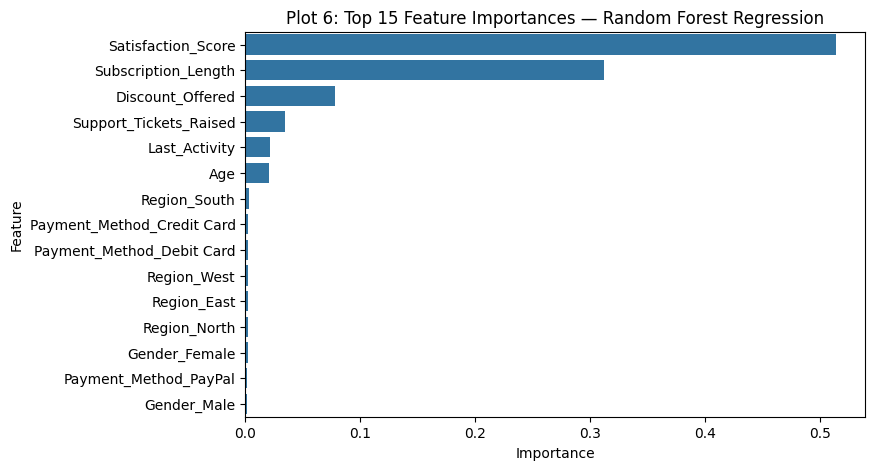

,Feature,Importance
3,Satisfaction_Score,0.513669
1,Subscription_Length,0.311978
4,Discount_Offered,0.078274
2,Support_Tickets_Raised,0.034878
5,Last_Activity,0.021591
0,Age,0.020750
10,Region_South,0.002746
12,Payment_Method_Credit Card,0.002577
13,Payment_Method_Debit Card,0.002345
11,Region_West,0.002270


In [20]:
ohe = rf_reg.named_steps["prep"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_feature_names = np.r_[num_cols, cat_feature_names]
importances = rf_reg.named_steps["model"].feature_importances_

fi = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(data=fi, x="Importance", y="Feature")
plt.title("Plot 6: Top 15 Feature Importances — Random Forest Regression")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

fi


## (d) ANN Regression using all features

An Artificial Neural Network (ANN) is trained using the fully preprocessed feature matrix.
- Input: all numeric + one-hot encoded categorical features
- Output: Monthly_Spend

Training curves (loss) are plotted to assess convergence and overfitting.


In [21]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X, y_spend, test_size=0.2, random_state=42
)

X_train_p = preprocess.fit_transform(X_train_d)
X_test_p = preprocess.transform(X_test_d)

# Convert sparse -> dense only if needed
if hasattr(X_train_p, "toarray"):
    X_train_p = X_train_p.toarray()
    X_test_p = X_test_p.toarray()

X_train_p.shape, X_test_p.shape


((4000, 15), (1000, 15))

In [22]:
ann = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1)  # regression output
])

ann.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError()]
)

ann.summary()


2025-12-21 19:08:11.867660: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2025-12-21 19:08:11.868479: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2025-12-21 19:08:11.868532: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2025-12-21 19:08:11.869192: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-21 19:08:11.869253: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,369 (40.50 KB)

 Trainable params: 10,369 (40.50 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = ann.fit(
    X_train_p, y_train_d,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


2025-12-21 19:08:15.598891: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - loss: 1791.0864 - mean_absolute_error: 41.1361 - val_loss: 1106.5101 - val_mean_absolute_error: 32.2299
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 363.8955 - mean_absolute_error: 15.3460 - val_loss: 19.9821 - val_mean_absolute_error: 3.2360
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 36.1266 - mean_absolute_error: 4.5009 - val_loss: 9.1063 - val_mean_absolute_error: 1.6418
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31.7621 - mean_absolute_error: 4.1716 - val_loss: 8.4412 - val_mean_absolute_error: 1.4493
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 32.1942 - mean_absolute_error: 4.1870 - val_loss: 8.3767 - val_mean_absolute_error: 1.4425
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31.5677 - mean_absolute_error: 4.1603 - val_loss: 8.2491 - val_mean_absolute_error: 1.3804
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 31.2312 - mean_absolute_error: 4.1224 - va

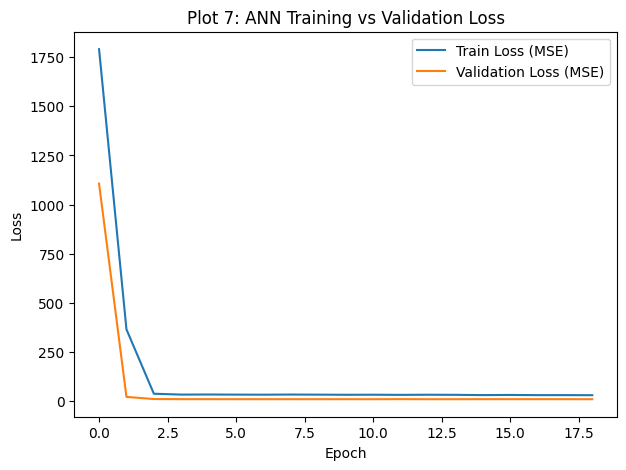

In [24]:
hist = pd.DataFrame(history.history)

plt.figure(figsize=(7,5))
plt.plot(hist["loss"], label="Train Loss (MSE)")
plt.plot(hist["val_loss"], label="Validation Loss (MSE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Plot 7: ANN Training vs Validation Loss")
plt.legend()
plt.show()


In [25]:
pred_d = ann.predict(X_test_p).ravel()
d_mae, d_rmse, d_r2 = regression_metrics(y_test_d, pred_d)

ann_metrics = pd.DataFrame([{
    "Model": "ANN Regression (All features)",
    "MAE": d_mae, "RMSE": d_rmse, "R2": d_r2
}])

ann_metrics


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


,Model,MAE,RMSE,R2
0,ANN Regression (All features),1.403865,3.234448,0.884274


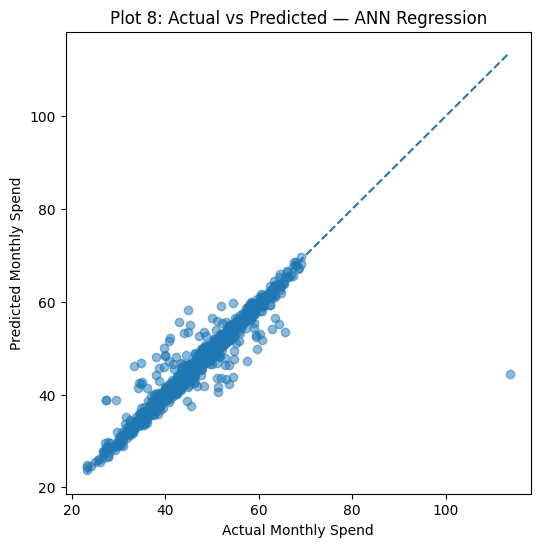

In [26]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_d, pred_d, alpha=0.5)
plt.plot([y_test_d.min(), y_test_d.max()], [y_test_d.min(), y_test_d.max()], linestyle="--")
plt.xlabel("Actual Monthly Spend")
plt.ylabel("Predicted Monthly Spend")
plt.title("Plot 8: Actual vs Predicted — ANN Regression")
plt.show()


## (e) Best model for predicting Monthly Spend

Models are compared using MAE, RMSE and R² on held-out test sets:
- Best single-feature model from (a)
- Multiple Linear Regression (b)
- Random Forest Regression (c)
- ANN Regression (d)

The best model is selected based on lowest error and strongest R², supported by plots.


In [45]:
best_a_row = best_a.to_dict()
best_a_row["Model"] = f"Best Single-feature ({best_a_row['Feature']} | {best_a_row['Model']})"

summary_e = pd.DataFrame([
    {"Model": best_a_row["Model"], "MAE": best_a_row["MAE"], "RMSE": best_a_row["RMSE"], "R2": best_a_row["R2"]},
    {"Model": "Multiple Linear Regression (Numeric only)", "MAE": b_mae, "RMSE": b_rmse, "R2": b_r2},
    {"Model": "Random Forest Regressor (All features)", "MAE": c_mae, "RMSE": c_rmse, "R2": c_r2},
    {"Model": "ANN Regression (All features)", "MAE": d_mae, "RMSE": d_rmse, "R2": d_r2},
]).sort_values("MAE")

summary_e

,Model,MAE,RMSE,R2
1,Multiple Linear Regression (Numeric only),1.358476,3.208505,0.886123
3,ANN Regression (All features),1.403865,3.234448,0.884274
2,Random Forest Regressor (All features),1.805876,3.460493,0.867534
0,Best Single-feature (Satisfaction_Score | Linear),5.160335,6.487249,0.534467


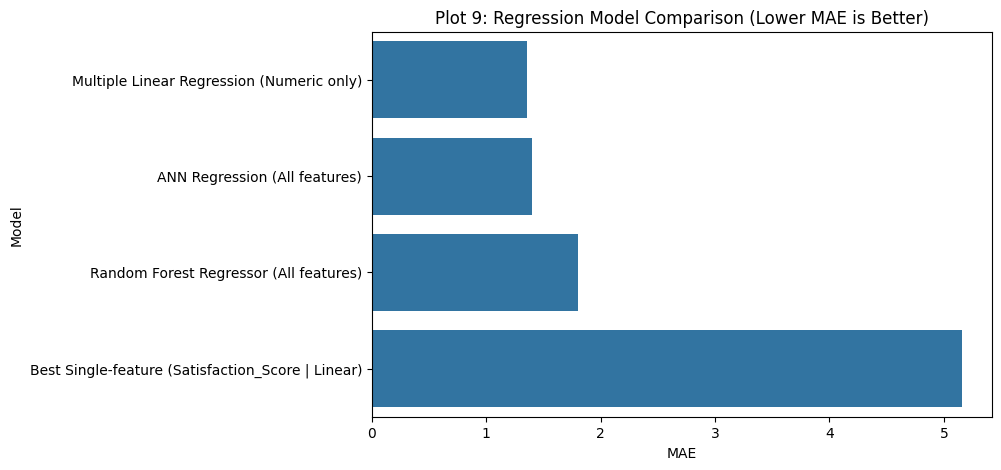

In [46]:
plt.figure(figsize=(8,5))
sns.barplot(data=summary_e, x="MAE", y="Model")
plt.title("Plot 9: Regression Model Comparison (Lower MAE is Better)")
plt.xlabel("MAE")
plt.ylabel("Model")
plt.show()

## (f) Predicting Customer Churn (Classification)

Two classification models are trained to predict `Churned`:
- Logistic Regression (baseline linear classifier)
- Random Forest Classifier (non-linear)

Performance is evaluated using:
Accuracy, Precision, Recall, F1-score, ROC-AUC,
plus a Confusion Matrix and ROC curve.


In [47]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X, y_churn, test_size=0.2, random_state=42, stratify=y_churn
)

X_train_fp = preprocess.fit_transform(X_train_f)
X_test_fp = preprocess.transform(X_test_f)

if hasattr(X_train_fp, "toarray"):
    X_train_fp = X_train_fp.toarray()
    X_test_fp = X_test_fp.toarray()


In [48]:
log_clf = LogisticRegression(max_iter=2000)
log_clf.fit(X_train_fp, y_train_f)

pred_log = log_clf.predict(X_test_fp)
proba_log = log_clf.predict_proba(X_test_fp)[:, 1]

log_metrics = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test_f, pred_log),
    "Precision": precision_score(y_test_f, pred_log),
    "Recall": recall_score(y_test_f, pred_log),
    "F1": f1_score(y_test_f, pred_log),
    "ROC_AUC": roc_auc_score(y_test_f, proba_log)
}

pd.DataFrame([log_metrics])


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806,0.788636,0.774554,0.781532,0.893205


In [51]:
rf_clf = RandomForestClassifier(n_estimators=400, random_state=42)
rf_clf.fit(X_train_fp, y_train_f)

pred_rf = rf_clf.predict(X_test_fp)
proba_rf = rf_clf.predict_proba(X_test_fp)[:, 1]

rf_metrics = {
    "Model": "Random Forest Classifier",
    "Accuracy": accuracy_score(y_test_f, pred_rf),
    "Precision": precision_score(y_test_f, pred_rf),
    "Recall": recall_score(y_test_f, pred_rf),
    "F1": f1_score(y_test_f, pred_rf),
    "ROC_AUC": roc_auc_score(y_test_f, proba_rf)
}

pd.DataFrame([rf_metrics])

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Random Forest Classifier,0.98,1.0,0.955357,0.977169,0.989444


In [52]:
clf_summary = pd.DataFrame([log_metrics, rf_metrics])
clf_summary


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.806,0.788636,0.774554,0.781532,0.893205
1,Random Forest Classifier,0.980,1.000000,0.955357,0.977169,0.989444


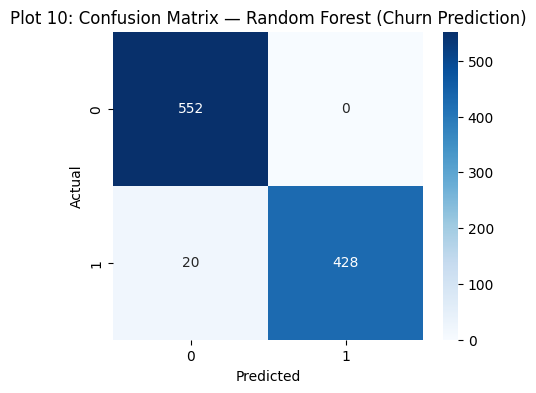

In [53]:
cm = confusion_matrix(y_test_f, pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Plot 10: Confusion Matrix — Random Forest (Churn Prediction)")
plt.show()


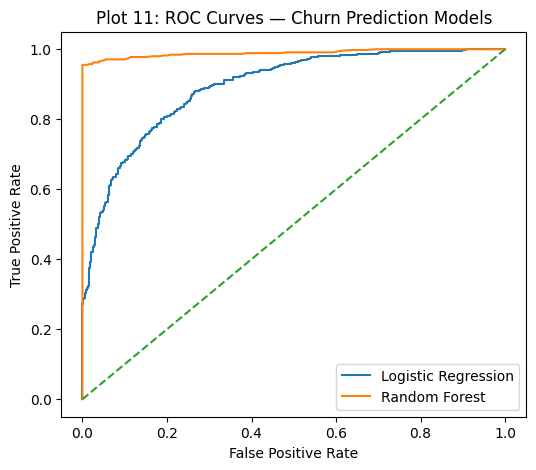

In [54]:
fpr1, tpr1, _ = roc_curve(y_test_f, proba_log)
fpr2, tpr2, _ = roc_curve(y_test_f, proba_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr1, tpr1, label="Logistic Regression")
plt.plot(fpr2, tpr2, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Plot 11: ROC Curves — Churn Prediction Models")
plt.legend()
plt.show()


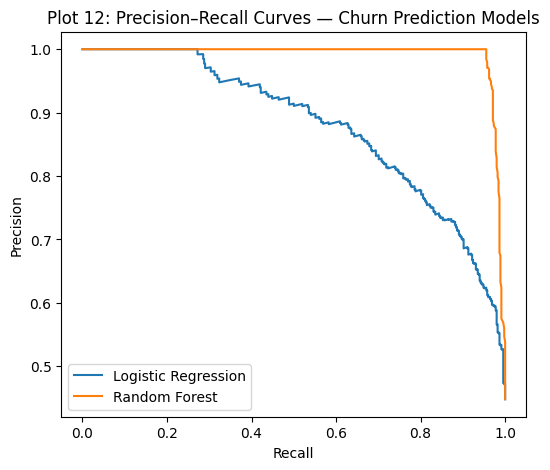

In [55]:
p1, r1, _ = precision_recall_curve(y_test_f, proba_log)
p2, r2, _ = precision_recall_curve(y_test_f, proba_rf)

plt.figure(figsize=(6,5))
plt.plot(r1, p1, label="Logistic Regression")
plt.plot(r2, p2, label="Random Forest")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Plot 12: Precision–Recall Curves — Churn Prediction Models")
plt.legend()
plt.show()


## (g) k-Means clustering for customer segmentation

k-Means clustering is applied to segment customers based on behaviour and value.

Selected features:
- Monthly_Spend, Subscription_Length, Satisfaction_Score, Discount_Offered, Last_Activity

Standardisation is applied because k-Means uses distances, and distance-based methods
are sensitive to differences in feature scale.


In [56]:
cluster_df = df[[
    "Monthly_Spend",
    "Subscription_Length",
    "Satisfaction_Score",
    "Discount_Offered",
    "Last_Activity"
]].dropna()

scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)


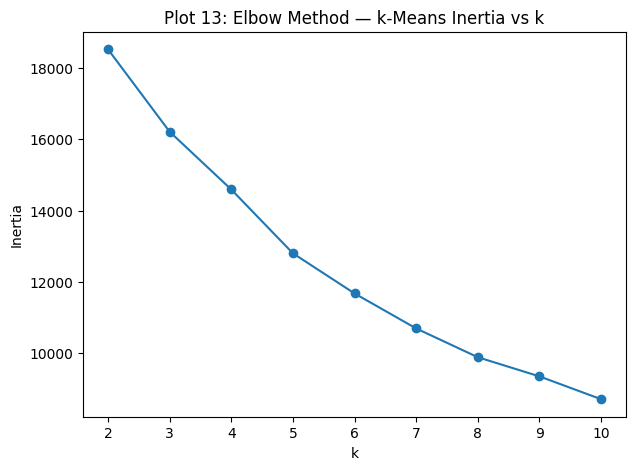

In [57]:
inertias = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(k_range), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Plot 13: Elbow Method — k-Means Inertia vs k")
plt.show()


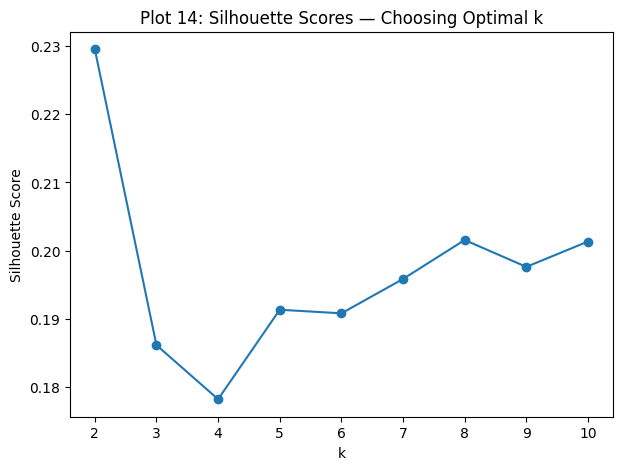

2

In [58]:
sil_scores = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(X_cluster)
    sil_scores.append(silhouette_score(X_cluster, labels))

plt.figure(figsize=(7,5))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Plot 14: Silhouette Scores — Choosing Optimal k")
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
best_k


In [59]:
kmeans = KMeans(n_clusters=best_k, random_state=42)
k_labels = kmeans.fit_predict(X_cluster)

g_metrics = pd.DataFrame([{
    "Algorithm": "k-Means",
    "k": best_k,
    "Silhouette": silhouette_score(X_cluster, k_labels),
    "Davies_Bouldin": davies_bouldin_score(X_cluster, k_labels)
}])

g_metrics


,Algorithm,k,Silhouette,Davies_Bouldin
0,k-Means,2,0.229512,1.633557


In [60]:
cluster_out = cluster_df.copy()
cluster_out["Cluster"] = k_labels

cluster_profile = cluster_out.groupby("Cluster").mean()
cluster_profile


,Monthly_Spend,Subscription_Length,Satisfaction_Score,Discount_Offered,Last_Activity
Cluster,,,,,
0,54.118160,36.208943,7.466561,13.172699,183.178472
1,38.957675,23.057825,3.675293,11.728512,179.666397


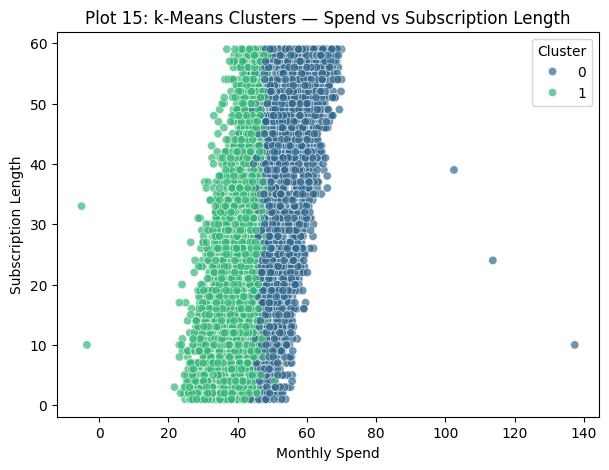

In [61]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=cluster_out["Monthly_Spend"],
    y=cluster_out["Subscription_Length"],
    hue=cluster_out["Cluster"],
    palette="viridis",
    alpha=0.7
)
plt.title("Plot 15: k-Means Clusters — Spend vs Subscription Length")
plt.xlabel("Monthly Spend")
plt.ylabel("Subscription Length")
plt.show()


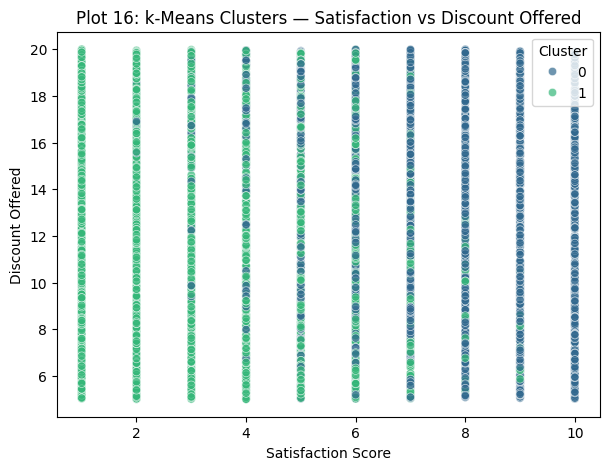

In [62]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=cluster_out["Satisfaction_Score"],
    y=cluster_out["Discount_Offered"],
    hue=cluster_out["Cluster"],
    palette="viridis",
    alpha=0.7
)
plt.title("Plot 16: k-Means Clusters — Satisfaction vs Discount Offered")
plt.xlabel("Satisfaction Score")
plt.ylabel("Discount Offered")
plt.show()


## (h) Comparison with another clustering algorithm (Hierarchical Clustering)

To evaluate whether k-Means provides the best segmentation, Hierarchical Clustering
(Agglomerative, complete linkage) is applied using the same feature space and number
of clusters. The comparison is based on:

- Silhouette Score (higher = better separation)
- Davies–Bouldin Index (lower = better compactness)
- Visual inspection of cluster overlap


In [63]:
hier = AgglomerativeClustering(n_clusters=best_k, linkage="complete")
h_labels = hier.fit_predict(X_cluster)

h_metrics = pd.DataFrame([{
    "Algorithm": "Hierarchical (Agglomerative, complete)",
    "k": best_k,
    "Silhouette": silhouette_score(X_cluster, h_labels),
    "Davies_Bouldin": davies_bouldin_score(X_cluster, h_labels)
}])

comparison_h = pd.concat([g_metrics, h_metrics], ignore_index=True)
comparison_h


,Algorithm,k,Silhouette,Davies_Bouldin
0,k-Means,2,0.229512,1.633557
1,"Hierarchical (Agglomerative, complete)",2,0.626275,0.572710


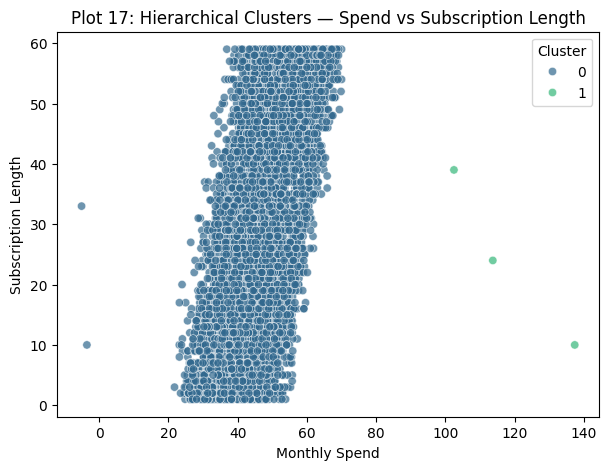

In [64]:
cluster_out_h = cluster_df.copy()
cluster_out_h["Cluster"] = h_labels

plt.figure(figsize=(7,5))
sns.scatterplot(
    x=cluster_out_h["Monthly_Spend"],
    y=cluster_out_h["Subscription_Length"],
    hue=cluster_out_h["Cluster"],
    palette="viridis",
    alpha=0.7
)
plt.title("Plot 17: Hierarchical Clusters — Spend vs Subscription Length")
plt.xlabel("Monthly Spend")
plt.ylabel("Subscription Length")
plt.show()


### Conclusion

The optimal k was selected using Silhouette analysis (supported by the Elbow plot).
Internal evaluation metrics (Silhouette and Davies–Bouldin) were used to compare
cluster quality between k-Means and Hierarchical Clustering.

The preferred clustering method is the one that provides **higher Silhouette Score**
and **lower Davies–Bouldin Index**, supported by clearer separation in the scatter plots.
